<a href="https://colab.research.google.com/github/joolsa/PersonaBase/blob/main/Notebooks/PersonaBench_PE05_Algorithm_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PersonaBench PE05 Algorithm Comparison

## Dataset

The dataset for this notebook can be found here: https://www.dropbox.com/scl/fi/i1idgttdw2fcr3dbspyje/DS06_YT.csv?rlkey=pyj1icys7mlxk7zgkp5epbk13&dl=0

Upload it to this repository and rename it to 'data.csv'.

## Initial Setup and Data Loading

In [3]:
from sklearn.decomposition import NMF
from sklearn.decomposition import PCA,IncrementalPCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import cluster
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)

In [4]:
df = pd.read_csv('data.csv')

In [5]:
df.shape

(1954, 12347)

In [6]:
original_features = df.drop('Unnamed: 0',axis=1)
original_features.shape

(1954, 12346)

In [7]:
original_features_trans = original_features.T
original_features_trans.shape

(12346, 1954)

## PCA 15 Personas

Principal Component Analysis (PCA) is used to identify the most important dimensions of variation in the demographic data and find representative personas for each component.

In [8]:
# Remove all non-numeric columns to get just the behavioral features
numeric_cols = df.select_dtypes(include=[np.number]).columns
demographic_features = df[numeric_cols]
print("Numeric features shape:", demographic_features.shape)
print("Number of features:", len(numeric_cols))

# Apply PCA to the cleaned numeric data
pca = PCA(n_components=15, random_state=42)
principalComponents_correct = pca.fit_transform(demographic_features)
print("Correct principalComponents shape:", principalComponents_correct.shape)

# Now find representatives using the demographic labels
def find_component_representatives(principalComponents, demographic_labels, pca_model):
    representatives = {}

    for component_idx in range(principalComponents.shape[1]):
        # Get scores for this component
        component_scores = principalComponents[:, component_idx]

        # Find demographic with highest absolute score
        max_idx = np.argmax(np.abs(component_scores))
        representative_demo = demographic_labels.iloc[max_idx]
        score = component_scores[max_idx]

        representatives[f'Component_{component_idx}'] = {
            'demographic': representative_demo,
            'score': score,
            'variance_explained': pca_model.explained_variance_ratio_[component_idx],
            'all_scores': component_scores
        }

        print(f"Component {component_idx}: {representative_demo} (score: {score:.2f}, var: {pca_model.explained_variance_ratio_[component_idx]:.3f})")

    return representatives

# Find the personas and create comprehensive data object
representatives = find_component_representatives(principalComponents_correct, df['Unnamed: 0'], pca)

# Create comprehensive PCA_personas data object
PCA_personas = {
    'method': 'PCA',
    'n_components': 15,
    'personas': representatives,
    'model': pca,
    'transformed_data': principalComponents_correct,
    'original_features': demographic_features,
    'demographic_labels': df['Unnamed: 0'],
    'variance_explained_ratio': pca.explained_variance_ratio_,
    'total_variance_explained': np.sum(pca.explained_variance_ratio_),
    'noise_variance': pca.noise_variance_,
    'feature_names': numeric_cols.tolist()
}

# Show some stats
print(f"\nTotal Percentage of Variance Explained: {np.round(PCA_personas['total_variance_explained'], 3)}")
print(f"Noise Variance: {PCA_personas['noise_variance']}")
print(f"PCA_personas data object created with {len(PCA_personas['personas'])} personas")

Numeric features shape: (1954, 12346)
Number of features: 12346
Correct principalComponents shape: (1954, 15)
Component 0: ZM_65-_female (score: -608435.76, var: 0.863)
Component 1: IN_25-34_male (score: 3106115.37, var: 0.072)
Component 2: IN_25-34_male (score: 1702972.11, var: 0.031)
Component 3: US_18-24_male (score: 700896.12, var: 0.006)
Component 4: IN_18-24_male (score: 855342.41, var: 0.005)
Component 5: IN_18-24_male (score: 613540.41, var: 0.005)
Component 6: CA_25-34_male (score: 509305.99, var: 0.003)
Component 7: US_25-34_male (score: -400772.67, var: 0.002)
Component 8: PK_25-34_male (score: 458493.67, var: 0.002)
Component 9: GB_25-34_male (score: 393362.56, var: 0.002)
Component 10: US_55-64_male (score: 259813.77, var: 0.001)
Component 11: PH_25-34_male (score: 358232.10, var: 0.001)
Component 12: US_65-_male (score: -151530.31, var: 0.001)
Component 13: US_45-54_male (score: -177513.15, var: 0.001)
Component 14: US_45-54_male (score: -190668.89, var: 0.001)

Total Per

## NMF 15 Personas

Non-negative Matrix Factorization (NMF) decomposes the data into non-negative components, which can be more interpretable for certain types of data.

In [9]:
# Remove all non-numeric columns to get just the behavioral features
numeric_cols = df.select_dtypes(include=[np.number]).columns
demographic_features = df[numeric_cols]
print("Numeric features shape:", demographic_features.shape)

# Apply NMF to the cleaned numeric data
model = NMF(n_components=15, random_state=0)
W = model.fit_transform(demographic_features)
print("W shape:", W.shape)

# Frobenius norm of the matrix difference, or beta-divergence, between the training data X and the reconstructed data WH from the fitted model.
print("Matrix Reconstruction Error (W*H):", model.reconstruction_err_)

# Find representatives for NMF components
def find_nmf_component_representatives(W_matrix, demographic_labels, nmf_model):
    representatives = {}

    for component_idx in range(W_matrix.shape[1]):
        # Get loadings for this component
        component_loadings = W_matrix[:, component_idx]

        # Find demographic with highest loading (NMF is non-negative)
        max_idx = np.argmax(component_loadings)
        representative_demo = demographic_labels.iloc[max_idx]
        loading = component_loadings[max_idx]

        representatives[f'Component_{component_idx}'] = {
            'demographic': representative_demo,
            'loading': loading,
            'all_loadings': component_loadings
        }

        print(f"Component {component_idx}: {representative_demo} (loading: {loading:.2f})")

    return representatives

# Find the personas
nmf_representatives = find_nmf_component_representatives(W, df['Unnamed: 0'], model)

# Create comprehensive NMF_personas data object
NMF_personas = {
    'method': 'NMF',
    'n_components': 15,
    'personas': nmf_representatives,
    'model': model,
    'W_matrix': W,  # Demographics x Components matrix
    'H_matrix': model.components_,  # Components x Features matrix
    'original_features': demographic_features,
    'demographic_labels': df['Unnamed: 0'],
    'reconstruction_error': model.reconstruction_err_,
    'n_iter': model.n_iter_,
    'original_variance': np.var(demographic_features.values),
    'feature_names': numeric_cols.tolist()
}

# Show variance explained equivalent for NMF
print(f"\nTotal variance in original data: {NMF_personas['original_variance']:.2f}")
print(f"Reconstruction error: {NMF_personas['reconstruction_error']:.2f}")
print(f"NMF converged in {NMF_personas['n_iter']} iterations")
print(f"NMF_personas data object created with {len(NMF_personas['personas'])} personas")

Numeric features shape: (1954, 12346)


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


W shape: (1954, 15)
Matrix Reconstruction Error (W*H): 1372068.615620226
Component 0: GY_13-17_male (loading: 203.45)
Component 1: IN_25-34_male (loading: 1129.70)
Component 2: US_35-44_male (loading: 174.23)
Component 3: US_18-24_female (loading: 41.65)
Component 4: IN_18-24_male (loading: 54.84)
Component 5: US_25-34_female (loading: 8.21)
Component 6: CA_25-34_male (loading: 18.13)
Component 7: US_18-24_male (loading: 3.18)
Component 8: PK_25-34_male (loading: 2.18)
Component 9: US_35-44_male (loading: 2.83)
Component 10: IN_35-44_male (loading: 0.45)
Component 11: PH_25-34_male (loading: 6.36)
Component 12: US_25-34_male (loading: 0.15)
Component 13: GB_25-34_male (loading: 8.81)
Component 14: US_55-64_male (loading: 38.60)

Total variance in original data: 41739683.40
Reconstruction error: 1372068.62
NMF converged in 200 iterations
NMF_personas data object created with 15 personas


## Clustering 15 Personas

Feature Agglomeration clustering groups similar features together and creates personas based on these feature clusters.

In [10]:
# Remove all non-numeric columns to get just the behavioral features
numeric_cols = df.select_dtypes(include=[np.number]).columns
demographic_features = df[numeric_cols]
print("Numeric features shape:", demographic_features.shape)

# Apply Feature Agglomeration to the cleaned numeric data
agglo = cluster.FeatureAgglomeration(n_clusters=15)
agglo.fit(demographic_features)
X_reduced = agglo.transform(demographic_features)
print("X_reduced shape:", X_reduced.shape)

# Find representatives for Feature Agglomeration clusters
def find_agglo_representatives(X_reduced, demographic_labels, agglo_model, feature_names):
    representatives = {}

    for cluster_idx in range(X_reduced.shape[1]):
        # Get values for this feature cluster
        cluster_values = X_reduced[:, cluster_idx]

        # Find demographic with highest value in this cluster
        max_idx = np.argmax(cluster_values)
        representative_demo = demographic_labels.iloc[max_idx]
        value = cluster_values[max_idx]

        # Find which original features belong to this cluster
        cluster_features = [feature_names[i] for i, label in enumerate(agglo_model.labels_) if label == cluster_idx]

        representatives[f'Cluster_{cluster_idx}'] = {
            'demographic': representative_demo,
            'value': value,
            'all_values': cluster_values,
            'original_features': cluster_features,
            'n_features_in_cluster': len(cluster_features)
        }

        print(f"Feature Cluster {cluster_idx}: {representative_demo} (value: {value:.2f}, {len(cluster_features)} features)")

    return representatives

# Find the personas
agglo_representatives = find_agglo_representatives(X_reduced, df['Unnamed: 0'], agglo, numeric_cols.tolist())

# Create comprehensive Agglo_personas data object
Agglo_personas = {
    'method': 'FeatureAgglomeration',
    'n_clusters': 15,
    'personas': agglo_representatives,
    'model': agglo,
    'transformed_data': X_reduced,
    'original_features': demographic_features,
    'demographic_labels': df['Unnamed: 0'],
    'feature_labels': agglo.labels_,
    'feature_names': numeric_cols.tolist(),
    'original_n_features': demographic_features.shape[1],
    'reduced_n_features': X_reduced.shape[1],
    'features_per_cluster': [np.sum(agglo.labels_ == i) for i in range(agglo.n_clusters)]
}

# Show which original features were grouped together
print(f"\nFeature clusters created: {Agglo_personas['n_clusters']}")
print(f"Original features: {Agglo_personas['original_n_features']}")
print(f"Reduced features: {Agglo_personas['reduced_n_features']}")
print(f"Features per cluster: {Agglo_personas['features_per_cluster']}")

# Optional: Show which features belong to each cluster
print(f"\nFeature assignment to clusters (first 10): {Agglo_personas['feature_labels'][:10]}")
print(f"Agglo_personas data object created with {len(Agglo_personas['personas'])} personas")

Numeric features shape: (1954, 12346)
X_reduced shape: (1954, 15)
Feature Cluster 0: IN_25-34_male (value: 124212.57, 37 features)
Feature Cluster 1: US_25-34_male (value: 308439.56, 9 features)
Feature Cluster 2: US_25-34_male (value: 1374.38, 12204 features)
Feature Cluster 3: US_35-44_male (value: 494791.00, 3 features)
Feature Cluster 4: DO_35-44_female (value: 1212838.00, 1 features)
Feature Cluster 5: US_25-34_male (value: 63878.91, 81 features)
Feature Cluster 6: US_25-34_male (value: 561004.00, 2 features)
Feature Cluster 7: IN_25-34_male (value: 3200512.00, 1 features)
Feature Cluster 8: US_18-24_male (value: 915474.00, 1 features)
Feature Cluster 9: PK_25-34_male (value: 513521.00, 1 features)
Feature Cluster 10: CA_25-34_male (value: 523760.00, 1 features)
Feature Cluster 11: US_35-44_male (value: 1661795.00, 1 features)
Feature Cluster 12: IN_18-24_male (value: 797517.00, 1 features)
Feature Cluster 13: US_18-24_female (value: 483574.00, 2 features)
Feature Cluster 14: GB_1

## Evaluation of Demographic Distribution in Persona Sets Created by Different Algorithms

This section compares how the three different algorithms (PCA, NMF, and Feature Agglomeration) distribute personas across different demographic categories.

Demographics Distribution Comparison

Country Distribution:
country     CA  DO  GB  GY  IN  PH  PK  US  ZM
algorithm                                     
Clustering   1   1   1   0   3   0   1   8   0
NMF          1   0   1   1   3   1   1   7   0
PCA          1   0   1   0   4   1   1   6   1

Country percentages:
country      CA   DO   GB   GY    IN   PH   PK    US   ZM
algorithm                                                
Clustering  6.7  6.7  6.7  0.0  20.0  0.0  6.7  53.3  0.0
NMF         6.7  0.0  6.7  6.7  20.0  6.7  6.7  46.7  0.0
PCA         6.7  0.0  6.7  0.0  26.7  6.7  6.7  40.0  6.7

Age Group Distribution:
age_group   13-17  18-24  25-34  35-44  45-54  55-64  65-
algorithm                                                
Clustering      0      4      8      3      0      0    0
NMF             1      3      7      3      0      1    0
PCA             0      3      7      0      2      1    2

Age group percentages:
age_group   13-17  18-24  25-34  35-44  45-54  55-64  

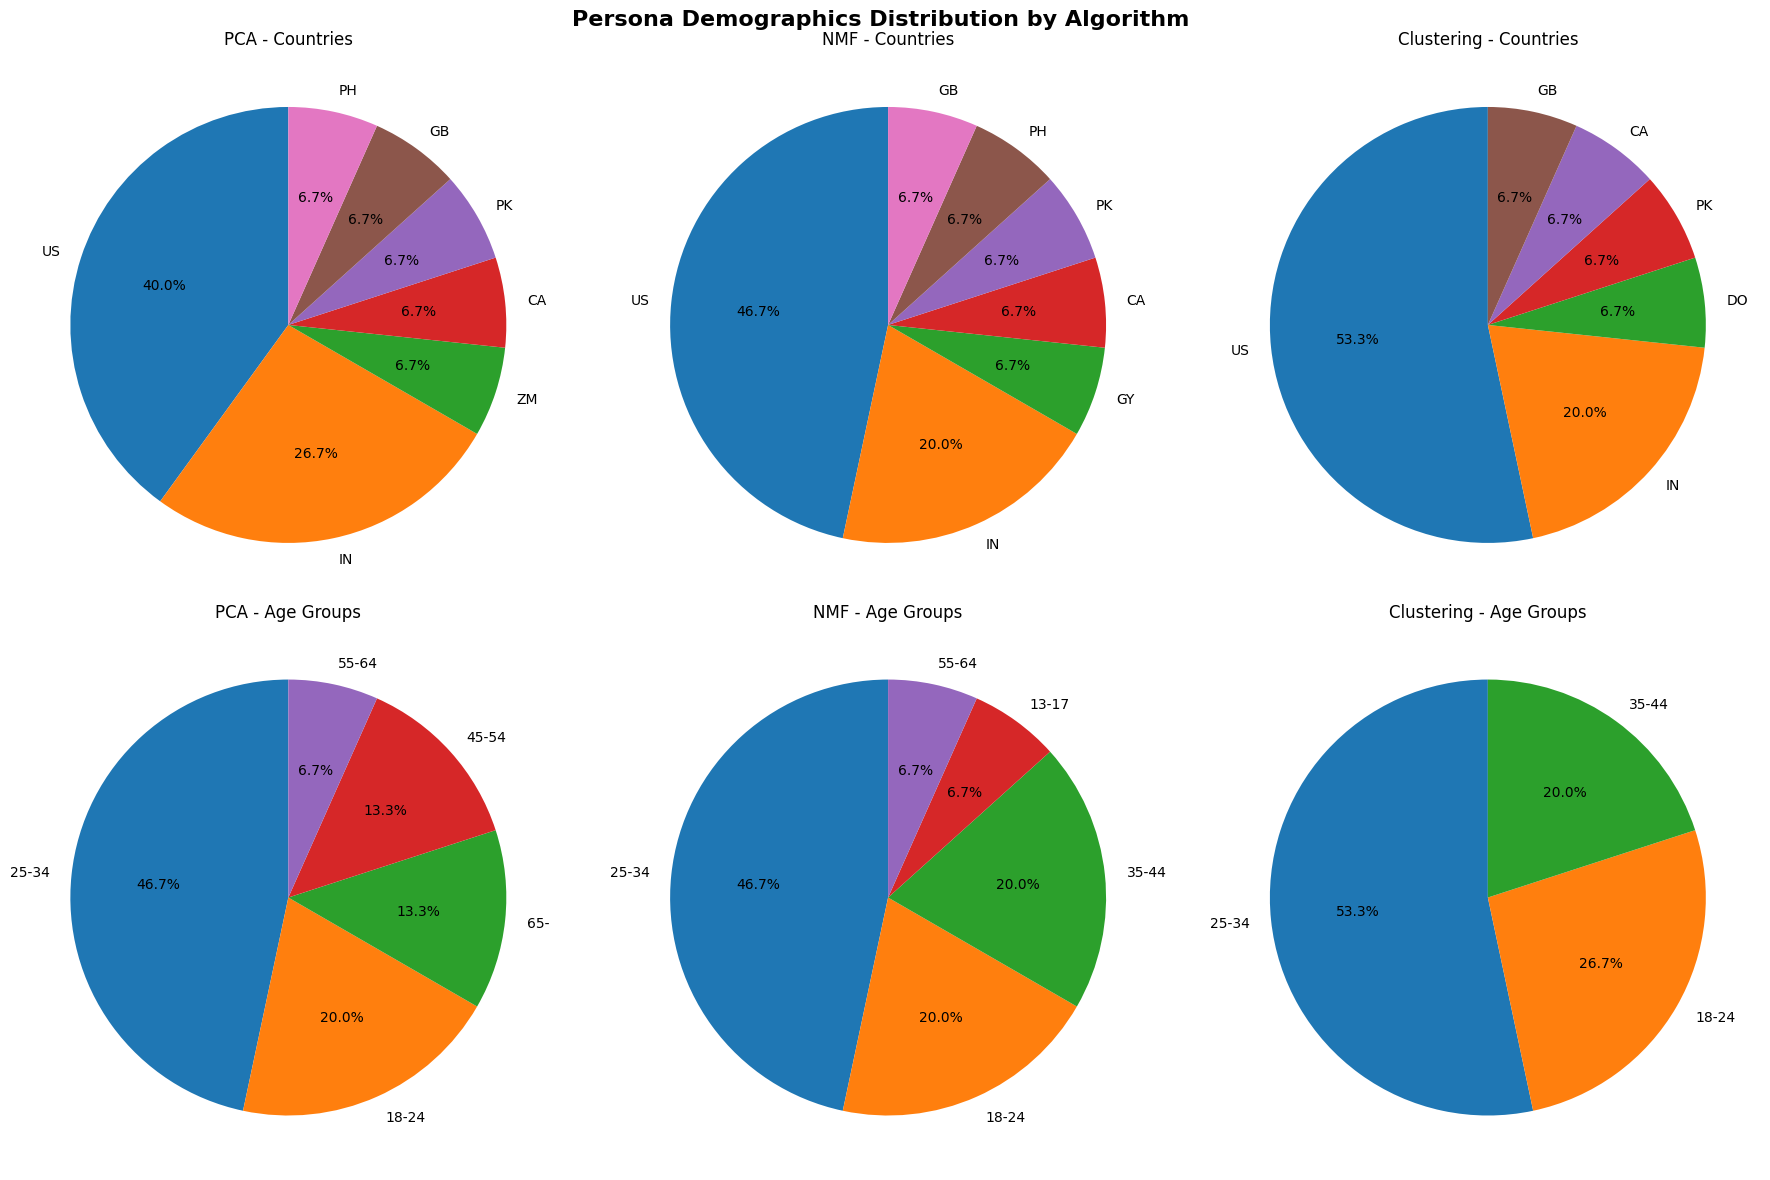

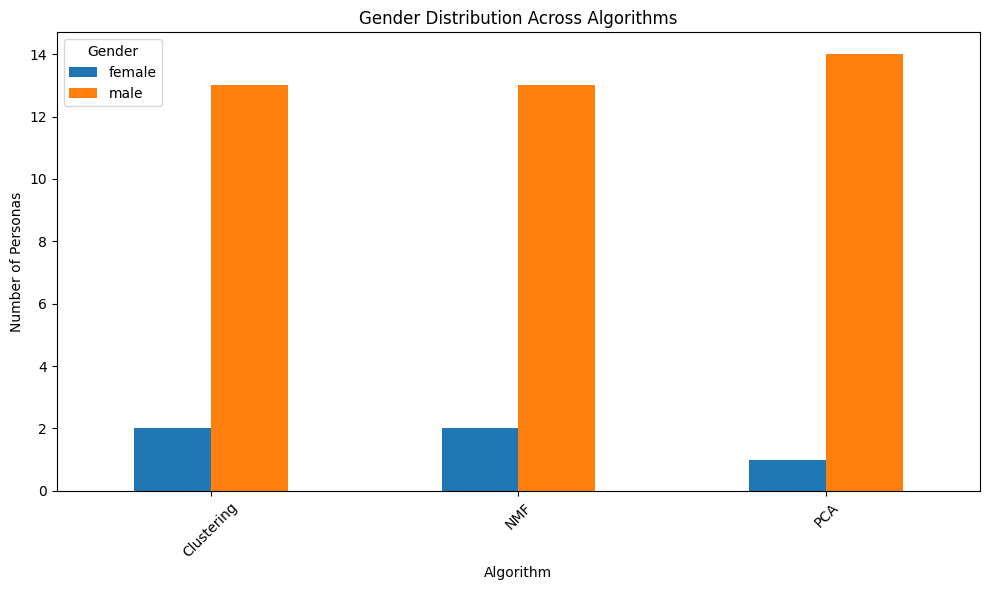


SUMMARY COMPARISON

PCA:
  Unique countries: 7
  Unique age groups: 5
  Gender balance: {'male': 14, 'female': 1}
  Most common country: US
  Most common age group: 25-34
  Countries unique to PCA: ['ZM']

NMF:
  Unique countries: 7
  Unique age groups: 5
  Gender balance: {'male': 13, 'female': 2}
  Most common country: US
  Most common age group: 25-34
  Countries unique to NMF: ['GY']

Clustering:
  Unique countries: 6
  Unique age groups: 3
  Gender balance: {'male': 13, 'female': 2}
  Most common country: US
  Most common age group: 25-34
  Countries unique to Clustering: ['DO']

Diversity Scores (Higher = More Diverse):
PCA:
  Country diversity: 1.62
  Age diversity: 1.40
  Gender diversity: 0.24
  Average diversity: 1.09
NMF:
  Country diversity: 1.58
  Age diversity: 1.36
  Gender diversity: 0.39
  Average diversity: 1.11
Clustering:
  Country diversity: 1.38
  Age diversity: 1.01
  Gender diversity: 0.39
  Average diversity: 0.93

Algorithm Diversity Ranking (by average diver

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def extract_demographics_from_personas(personas_dict):
    """Extract gender, age group, and country from persona demographic labels"""
    demographics = []

    # Rename FeatureAgglomeration to Clustering
    algorithm_name = 'Clustering' if personas_dict['method'] == 'FeatureAgglomeration' else personas_dict['method']

    for persona_key, persona_data in personas_dict['personas'].items():
        demo_label = persona_data['demographic']

        # Split the demographic label (format: COUNTRY_AGEGROUP_GENDER)
        parts = demo_label.split('_')

        if len(parts) >= 3:
            country = parts[0]
            age_group = parts[1]
            gender = parts[2]
        else:
            # Handle any unexpected formats
            country = 'Unknown'
            age_group = 'Unknown'
            gender = 'Unknown'

        demographics.append({
            'algorithm': algorithm_name,
            'persona': persona_key,
            'demographic_label': demo_label,
            'country': country,
            'age_group': age_group,
            'gender': gender
        })

    return pd.DataFrame(demographics)

# Extract demographics from all three algorithms
pca_demos = extract_demographics_from_personas(PCA_personas)
nmf_demos = extract_demographics_from_personas(NMF_personas)
agglo_demos = extract_demographics_from_personas(Agglo_personas)

# Combine all demographics
all_demographics = pd.concat([pca_demos, nmf_demos, agglo_demos], ignore_index=True)

print("Demographics Distribution Comparison")
print("=" * 50)

# Country distribution
print("\nCountry Distribution:")
country_dist = all_demographics.groupby(['algorithm', 'country']).size().unstack(fill_value=0)
print(country_dist)
print(f"\nCountry percentages:")
country_pct = country_dist.div(country_dist.sum(axis=1), axis=0) * 100
print(country_pct.round(1))

# Age group distribution
print("\nAge Group Distribution:")
age_dist = all_demographics.groupby(['algorithm', 'age_group']).size().unstack(fill_value=0)
print(age_dist)
print(f"\nAge group percentages:")
age_pct = age_dist.div(age_dist.sum(axis=1), axis=0) * 100
print(age_pct.round(1))

# Gender distribution
print("\nGender Distribution:")
gender_dist = all_demographics.groupby(['algorithm', 'gender']).size().unstack(fill_value=0)
print(gender_dist)
print(f"\nGender percentages:")
gender_pct = gender_dist.div(gender_dist.sum(axis=1), axis=0) * 100
print(gender_pct.round(1))

# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Persona Demographics Distribution by Algorithm', fontsize=16, fontweight='bold')

# Country distributions
for i, algo in enumerate(['PCA', 'NMF', 'Clustering']):
    algo_data = all_demographics[all_demographics['algorithm'] == algo]
    country_counts = algo_data['country'].value_counts()

    axes[0, i].pie(country_counts.values, labels=country_counts.index, autopct='%1.1f%%', startangle=90)
    axes[0, i].set_title(f'{algo} - Countries')

# Age group distributions
for i, algo in enumerate(['PCA', 'NMF', 'Clustering']):
    algo_data = all_demographics[all_demographics['algorithm'] == algo]
    age_counts = algo_data['age_group'].value_counts()

    axes[1, i].pie(age_counts.values, labels=age_counts.index, autopct='%1.1f%%', startangle=90)
    axes[1, i].set_title(f'{algo} - Age Groups')

plt.tight_layout()
plt.show()

# Gender comparison bar chart
plt.figure(figsize=(10, 6))
gender_comparison = all_demographics.groupby(['algorithm', 'gender']).size().unstack(fill_value=0)
gender_comparison.plot(kind='bar', ax=plt.gca())
plt.title('Gender Distribution Across Algorithms')
plt.xlabel('Algorithm')
plt.ylabel('Number of Personas')
plt.legend(title='Gender')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*50)
print("SUMMARY COMPARISON")
print("="*50)

# Find unique countries for each algorithm
all_countries = set(all_demographics['country'].unique())
algorithm_countries = {}
for algo in ['PCA', 'NMF', 'Clustering']:
    algo_data = all_demographics[all_demographics['algorithm'] == algo]
    algorithm_countries[algo] = set(algo_data['country'].unique())

for algo in ['PCA', 'NMF', 'Clustering']:
    algo_data = all_demographics[all_demographics['algorithm'] == algo]

    # Find countries unique to this algorithm
    other_algos = [a for a in ['PCA', 'NMF', 'Clustering'] if a != algo]
    other_countries = set()
    for other_algo in other_algos:
        other_countries.update(algorithm_countries[other_algo])

    unique_countries = algorithm_countries[algo] - other_countries

    print(f"\n{algo}:")
    print(f"  Unique countries: {algo_data['country'].nunique()}")
    print(f"  Unique age groups: {algo_data['age_group'].nunique()}")
    print(f"  Gender balance: {algo_data['gender'].value_counts().to_dict()}")
    print(f"  Most common country: {algo_data['country'].mode().iloc[0]}")
    print(f"  Most common age group: {algo_data['age_group'].mode().iloc[0]}")
    if unique_countries:
        print(f"  Countries unique to {algo}: {sorted(list(unique_countries))}")
    else:
        print(f"  Countries unique to {algo}: None")

# Calculate diversity scores (entropy)
from scipy.stats import entropy

print(f"\nDiversity Scores (Higher = More Diverse):")
for algo in ['PCA', 'NMF', 'Clustering']:
    algo_data = all_demographics[all_demographics['algorithm'] == algo]

    country_entropy = entropy(algo_data['country'].value_counts().values)
    age_entropy = entropy(algo_data['age_group'].value_counts().values)
    gender_entropy = entropy(algo_data['gender'].value_counts().values)

    # Calculate average diversity
    average_diversity = (country_entropy + age_entropy + gender_entropy) / 3

    print(f"{algo}:")
    print(f"  Country diversity: {country_entropy:.2f}")
    print(f"  Age diversity: {age_entropy:.2f}")
    print(f"  Gender diversity: {gender_entropy:.2f}")
    print(f"  Average diversity: {average_diversity:.2f}")

# Overall diversity ranking
print(f"\nAlgorithm Diversity Ranking (by average diversity):")
diversity_scores = {}
for algo in ['PCA', 'NMF', 'Clustering']:
    algo_data = all_demographics[all_demographics['algorithm'] == algo]

    country_entropy = entropy(algo_data['country'].value_counts().values)
    age_entropy = entropy(algo_data['age_group'].value_counts().values)
    gender_entropy = entropy(algo_data['gender'].value_counts().values)
    average_diversity = (country_entropy + age_entropy + gender_entropy) / 3

    diversity_scores[algo] = average_diversity

# Sort by diversity score
sorted_diversity = sorted(diversity_scores.items(), key=lambda x: x[1], reverse=True)
for rank, (algo, score) in enumerate(sorted_diversity, 1):
    print(f"  {rank}. {algo}: {score:.2f}")

## Summary

This notebook compares three different algorithms for generating personas from demographic data:

1. **PCA (Principal Component Analysis)**: Finds linear combinations of features that explain the most variance in the data
2. **NMF (Non-negative Matrix Factorization)**: Decomposes data into non-negative components, which can be more interpretable
3. **Feature Agglomeration Clustering**: Groups similar features together and creates personas based on feature clusters

The evaluation section analyzes how each algorithm distributes personas across different demographic categories (country, age group, gender) and calculates diversity scores using entropy measures to determine which algorithm produces the most diverse set of personas.